In [319]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

In [320]:
df= pd.read_csv('diabetes_dataset.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [321]:
df.value_counts()

Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin  BMI   DiabetesPedigreeFunction  Age  Outcome
6            148      72             35             0        33.6  0.627                     50   1          1
1            85       66             29             0        26.6  0.351                     31   0          1
8            183      64             0              0        23.3  0.672                     32   1          1
1            89       66             23             94       28.1  0.167                     21   0          1
0            137      40             35             168      43.1  2.288                     33   1          1
                                                                                                            ..
10           101      76             48             180      32.9  0.171                     63   0          1
2            122      70             27             0        36.8  0.340                     27   0          1
5     

In [322]:
x= df.iloc[:,:-1]
y= df.iloc[:,-1]

In [323]:
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.25,random_state=50)

In [324]:
dt= DecisionTreeClassifier(max_depth=5)

In [325]:
dt.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=5)

In [326]:
y_pred= dt.predict(x_test)

In [327]:
from sklearn.metrics import classification_report, confusion_matrix, recall_score, precision_score, accuracy_score

In [328]:
accuracy_score(y_test, y_pred)

0.765625

In [329]:
confusion_matrix(y_test, y_pred)

array([[103,  19],
       [ 26,  44]], dtype=int64)

In [330]:
precision_score(y_test, y_pred)

0.6984126984126984

In [331]:
recall_score(y_test, y_pred)

0.6285714285714286

In [332]:
from sklearn.tree import plot_tree

In [333]:
import matplotlib.pyplot as plt

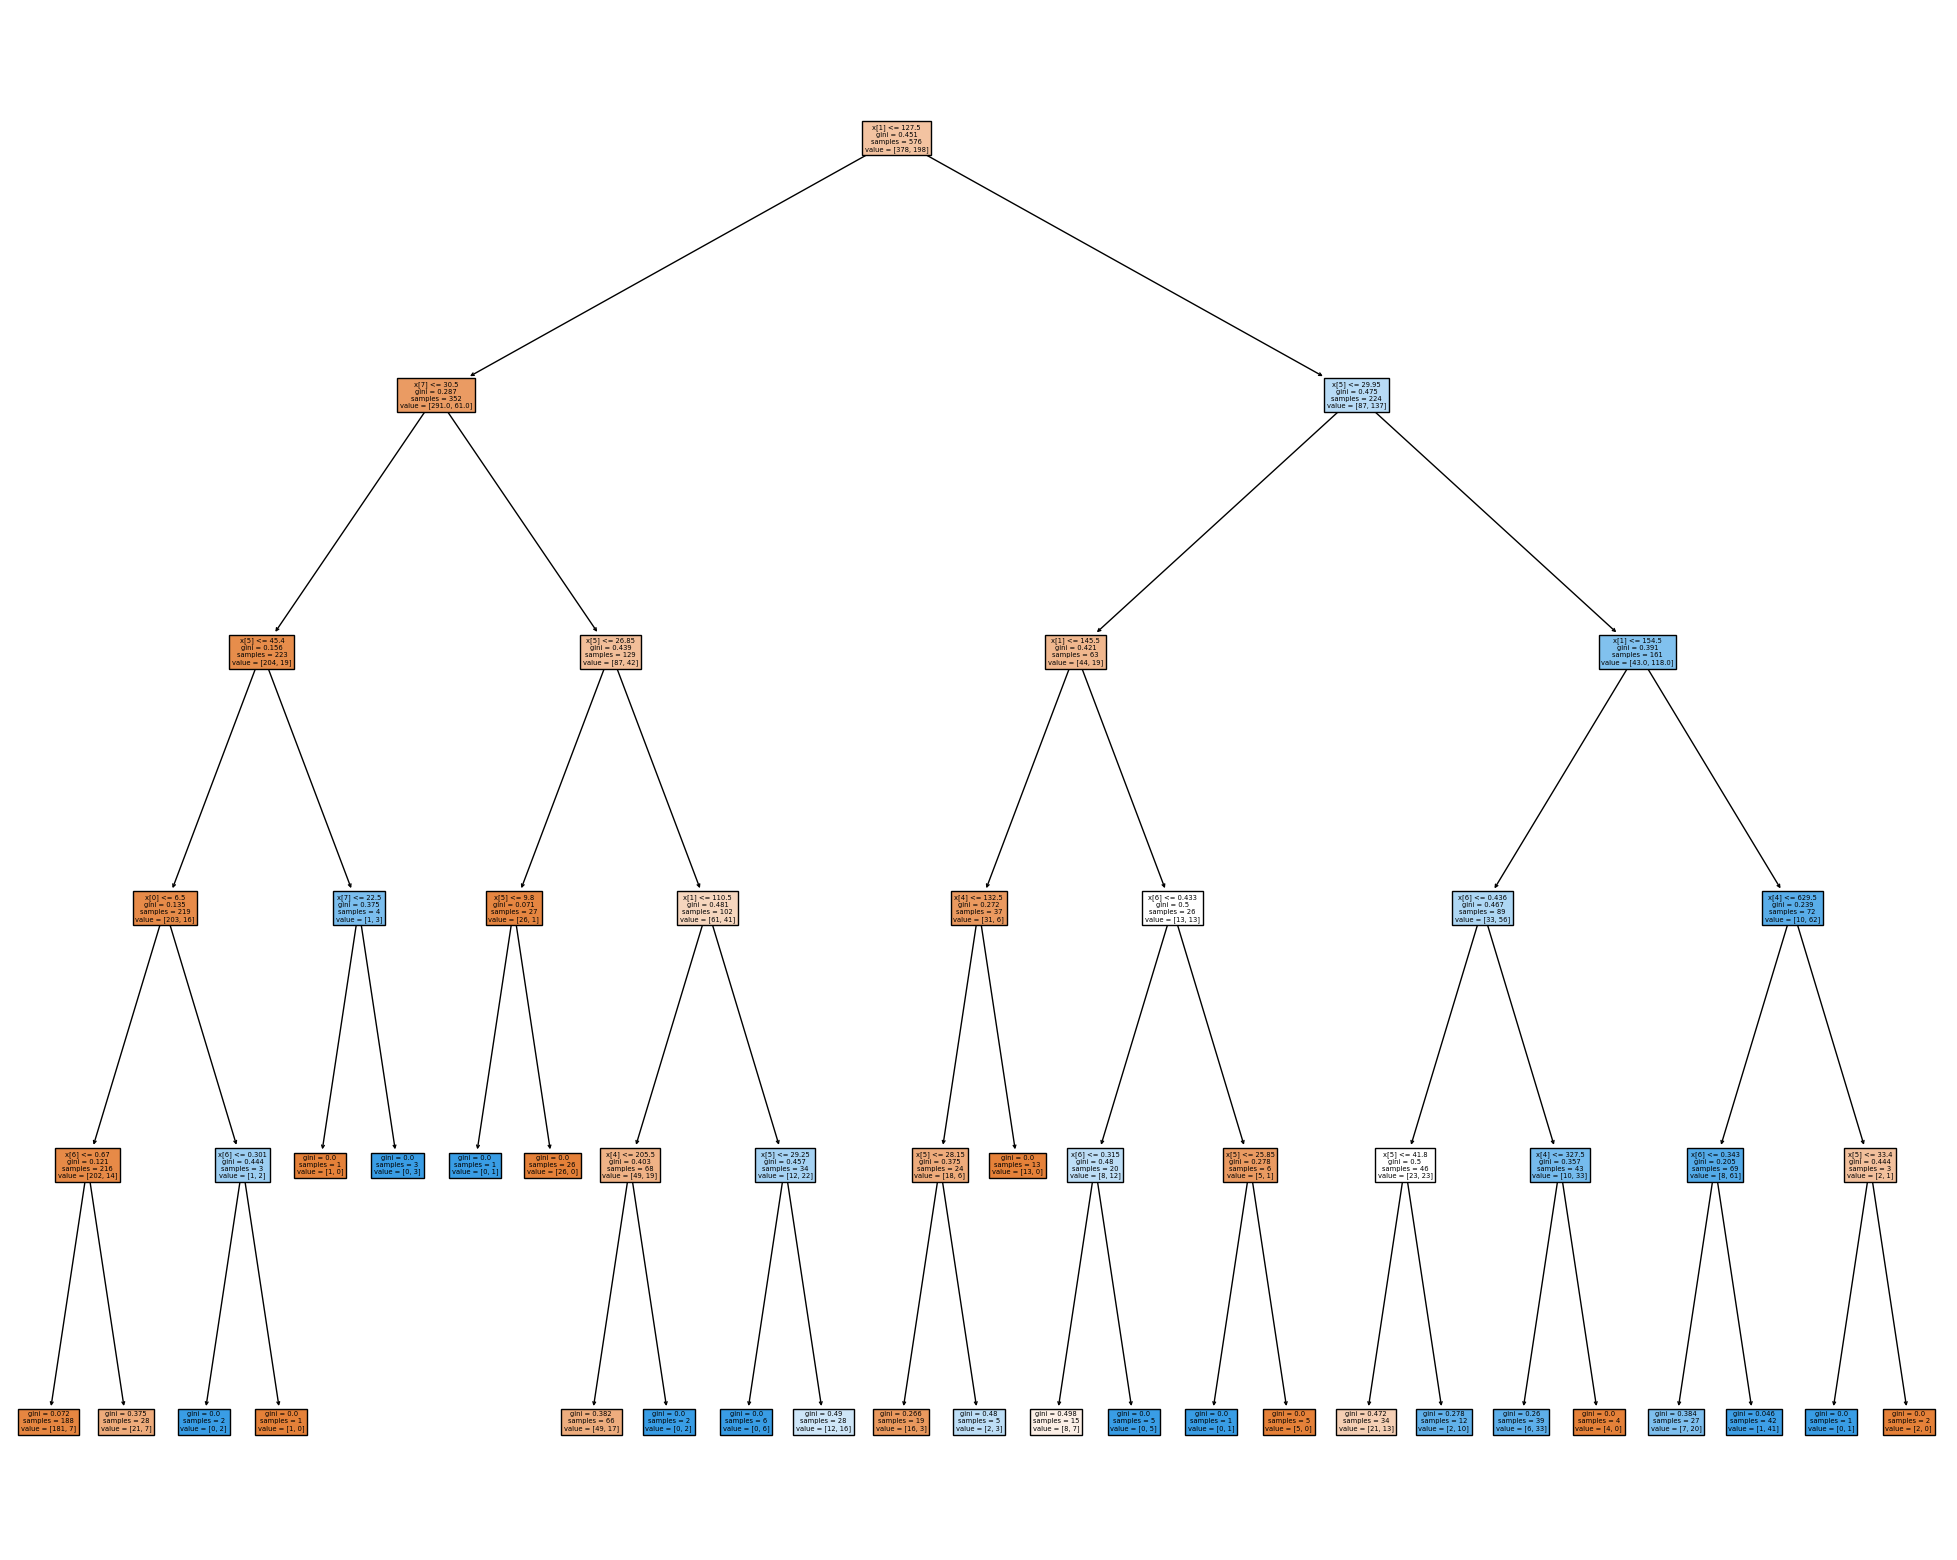

In [334]:
plt.figure(figsize=(25,20))
fig=plot_tree(dt, filled=True)
plt.show()

In [335]:
from sklearn.model_selection import GridSearchCV

In [336]:
model=DecisionTreeClassifier()

In [337]:
params={
    'criterion':['gini','entropy'],
    'max_depth':[3,4,5,6,7,8,9,10,11]
}
    


In [338]:
cv=GridSearchCV(model,param_grid=params,cv=4,scoring='accuracy')

In [339]:
cv.fit(x_train,y_train)

GridSearchCV(cv=4, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 4, 5, 6, 7, 8, 9, 10, 11]},
             scoring='accuracy')

In [340]:
cv.best_params_

{'criterion': 'gini', 'max_depth': 5}

In [341]:
tree= DecisionTreeClassifier(criterion='gini',max_depth=5)

In [342]:
tree.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=5)

In [343]:
y_pred = tree.predict(x_test)

In [344]:
accuracy_score(y_test,y_pred)

0.7604166666666666